<a href="https://colab.research.google.com/github/Marco-Poelsma/AC05_The_Playlist/blob/main/AC05_The_Playlist_MarcoPoelsma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AC05-The Playlist

![the-playlist](https://musiccustodian.com/wp-content/uploads/2025/01/Spotify.jpg)

# Nom alumn@

> Marco Poelsma

# Objectiu

A partir de les [dades de 32.000 cançons de Spotify](https://raw.githubusercontent.com/raimonizard/datasets/refs/heads/main/spotify_songs_sub.csv), crear un **model de regressió logística** que permeti **determinar la tipologia de música de cada cançó** en funció de les seves característiques determinades per uns indicadors.

Aquest conjunt de dades està dissenyat per a **entrenar algoritmes de decisió** i en aquest cas, per a determinar la tipologia de música de cada cançó.
Inclou 32.000 mostres on cada fila conté els detalls d'una cançó amb els següents atributs:

* **track_artist**: nom de l'artista de la cançó
* **danceability**: índex de ballabilitat de la cançó
* **energy**: índex que quantifica quan energètica és la peça
* **key**: índex de paràmetre musical
* **loudness**: índex que avalua la quantitat de greus que conté la cançó
* **mode**: índex de paràmetre musical
* **speechiness**: índex que avalua quanta lletra cantada conté la cançó
* **acousticness**: índex que avalua si la peça està gravada en acústic
* **instrumentalness**: índex que avalua si la cançó és de tipus instrumental
* **liveness**: índex que avalua si la cançó ha estat gravada en un concert en directe
* **valence**: índex de paràmetre musical
* **tempo**: índex de paràmetre musical
* **track_popularity**: índex que avalua quant popular és la cançó

L'objectiu és determinar si les cançons són de tipus:
| id | song_genre |
| --- | --- |
| 0 | pop |
| 1 | rap |
| 2 | rock |
| 3 | latin |
| 4 | r&b |
| 5 | edm |

El nostre objectiu és el d'**analitzar es dades (EDA)** i **entrenar un model de classificació** usant una **regressió logística** que sigui **capaç de catalogar les cançons per tipologia** en funció de les característiques determinades per les variables independents.

Per tant, la nostra variable objectiu és **song_genre**.

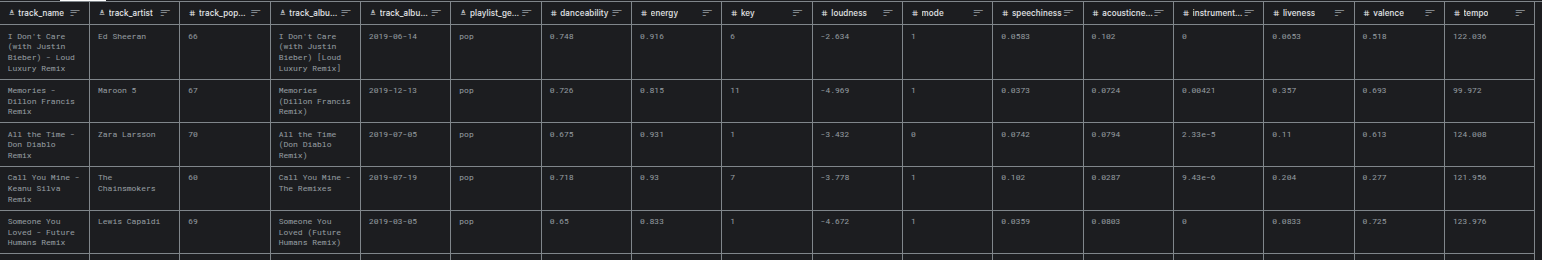

Un cop tinguem aquest model entrenat, n'analitzarem la seva precisió per tal de valorar si és vàlid per a ser usat per a **determinar la tipologia de música** d'una cançó si en coneixem les dades dels seus índex músicals.

---

# Tasques a fer

## EDA

Fer un anàlisi exploratori de les dades:
*   Quantes files té
*   Visualitzar les seves 5 primeres i últimes files
*   Quines columnes té i la seva tiplogia
*   Quants nuls té
*   Correlació entre columnes
*   **Quantes cançons hi ha per tipologia de música (diagrama de barres i piechart)**
* **Quantes cançons hi ha per artista**
* **Quantes cançons es publiquen per any**
*   etc.

### Importació de llibreries

Començo, com sempre, important les llibreries necessàries per a fer el processament de les dades.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

I comprovo que s'hagin importat correctament

In [ ]:
print(pd.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(sns.__version__)
print(sklearn.__version__)

2.2.2
2.0.2
3.10.0
0.13.2
1.6.1


### Importació de dades

Importaré les dades mitjançant la llibreria pandas

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/raimonizard/datasets/refs/heads/main/spotify_songs_sub.csv")

I comprovaré que s'hagin importat correctament

In [ ]:
df.head(5)

,track_name,track_artist,track_album_name,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,song_genre
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,66,pop
1,Memories - Dillon Francis Remix,Maroon 5,Memories (Dillon Francis Remix),2019-12-13,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,67,pop
2,All the Time - Don Diablo Remix,Zara Larsson,All the Time (Don Diablo Remix),2019-07-05,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,70,pop
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,Call You Mine - The Remixes,2019-07-19,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,60,pop
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,Someone You Loved (Future Humans Remix),2019-03-05,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,69,pop


In [ ]:
df.tail(5)

,track_name,track_artist,track_album_name,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity,song_genre
32828,City Of Lights - Official Radio Edit,Lush & Simon,City Of Lights (Vocal Mix),2014-04-28,0.428,0.922,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375,42,edm
32829,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,Closer Remixed,2013-03-08,0.522,0.786,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120,20,edm
32830,Sweet Surrender - Radio Edit,Starkillers,Sweet Surrender (Radio Edit),2014-04-21,0.529,0.821,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112,14,edm
32831,Only For You - Maor Levi Remix,Mat Zo,Only For You (Remixes),2014-01-01,0.626,0.888,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432,15,edm
32832,Typhoon - Original Mix,Julian Calor,Typhoon/Storm,2014-03-03,0.603,0.884,5,-4.571,0,0.0385,0.000133,0.341000,0.7420,0.0894,127.984,337500,27,edm


Com la comanda `df.tail(5)`, mostra les últimes 5 files del dataframe i el dataframe és indexat a 0, també sé que, en total, aquest dataset te 32833 files.

### Identificació dels tipus de variables

In [ ]:
df.dtypes

,0
track_name,object
track_artist,object
track_album_name,object
track_album_release_date,object
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64


Tenim bastantes dades que el dataset no pot identificar com un tipus de dada específica (tipus genèric `object`). De moment, eliminaré les dades que no farem servir.

In [ ]:
df = df[['track_artist', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness' , 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_popularity', 'song_genre']]

Per tant, els tipus de dades reals són els següents:

In [ ]:
df.dtypes

,0
track_artist,object
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64
acousticness,float64
instrumentalness,float64
liveness,float64


## Identificar variables independents (X) i dependents (y)

Al data set donat, hi ha més columnes de les que farem servir per a entrenar l'algoritme. Només ens interessen els índex musicals esmentats anteriorment.

In [ ]:
# X =
X = df[['track_artist', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness' , 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_popularity']]
# y =
y = df['song_genre']

I comprovo que s'hagi executat correctament

In [ ]:
X.head(5)

,track_artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_popularity
0,Ed Sheeran,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,66
1,Maroon 5,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,67
2,Zara Larsson,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,70
3,The Chainsmokers,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,60
4,Lewis Capaldi,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,69


In [ ]:
y.head(5)

,song_genre
0,pop
1,pop
2,pop
3,pop
4,pop


## Mapejar dades qualitatives

Usant mapes (diccionaris), convertir les dades qualitatives que contenen descripcions textuals a quantitatives (numèriques) per tal de que sigui més fàcil entrenar el model de ML.

> Ajuda: Primer hem de crear un llistat de Python amb els valors únics de cada variable que conté valors alfanumèrics usant la funció `unique()`, després crear un llistat amb valors enters per a usar com a id de cada valor únic usant range() i finalment podem usar la funció `dict(zip())` per a crear un diccionari ajuntant les dues llistes per la qual trobarem una ajuda al final d'aquest enunciat.

### Mapejar la variable dependent

Primer creo el diccionari

In [ ]:
song_genre = ['pop', 'rap', 'rock', 'latin', 'r&b' , 'edm']
song_genre_ids = range(6)

y_mapping_dict = dict(zip(song_genre, song_genre_ids))

print(y_mapping_dict)

{'pop': 0, 'rap': 1, 'rock': 2, 'latin': 3, 'r&b': 4, 'edm': 5}


... i ara mapejo el meu dataframe fent servir el diccionari com a guia

In [ ]:
y = y.replace(y_mapping_dict)

# I comprovo que s'hagin efectuat els canvis..
y.head(5)

/tmp/ipykernel_282/2072600703.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace(y_mapping_dict)


,song_genre
0,0
1,0
2,0
3,0
4,0


### Mapejar la variable independent

S'han de mapejar la columna `track_artist` de la variable independent.

#### Identificar tots els valors únics de la columna `track_artist`

Al principi, volia començar definint una funció `totuple(a)` que convertís la llista a una tupla, que es pot trobar a [StackOverflow](https://stackoverflow.com/questions/10016352/convert-numpy-array-to-tuple)


In [ ]:
# Source - https://stackoverflow.com/a/10016613
# Posted by Bi Rico, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-08, License - CC BY-SA 3.0

def totuple(a):
    try:
        return tuple(totuple(i) for i in a)
    except TypeError:
        return a


I ara puc fer servir la funció per a convertir tots el ndarray de valors únics a una tupla.

In [ ]:
# Línia comentada per si es fa servir un dataset de menys de 1000 valors únics en el futur.
# Aquest dataset té 10 693 artistes únics. Així que no serveix perquè excedeix el límit de
# recursió de Python (i com que no som propietaris del sistema no podem canviar-lo).
# track_artist_unique = totuple(X['track_artist'].unique())

RecursionError: maximum recursion depth exceeded

`RecursionError: maximum recursion depth exceeded`

Llavors, això significa que he de incrementar el límit de recursió de Python per a que funcioni amb el nombre d'artistes únics del dataframe.

Per a evitar aquest error, i tot i que és una mica més lent, faré servir un bucle en comptes de recursivitat. Addicionalment, hauré de fer servir una llista en comptes d'una tupla per a afegir valors, però podré fer servir una tupla més endavant per a fer el merge dels dos arrays.

In [ ]:
def tolist(a):
    l = []
    for i in a:
        l.append(i)
    return tuple(l)

I ara puc fer servir aquesta funció per a convertir el `ndarray` d'artistes únics a una tupla.

In [ ]:
track_artist_unique = tolist(X['track_artist'].unique())

I també generaré un rang del tamany d'aquesta tupla per fer el mapejat

In [ ]:
tau_indexes = tuple(range(len(track_artist_unique)))

I finalment puc unir les tuples amb `zip()`

In [ ]:
tau_mapping_dict = dict(zip(track_artist_unique, tau_indexes))

Ara faig servir `replace` per a fer el mapejat de les dades.

In [ ]:
X['track_artist'] = X['track_artist'].map(tau_mapping_dict)

/tmp/ipykernel_282/1368148660.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['track_artist'] = X['track_artist'].map(tau_mapping_dict)


Comprovo que s'hagi executat bé la comanda

In [ ]:
X.head(5)

,track_artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_popularity
0,0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,66
1,1,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,67
2,2,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,70
3,3,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,60
4,4,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,69


In [ ]:
X.tail(5)

,track_artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_popularity
32828,183,0.428,0.922,2,-1.814,1,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,42
32829,10691,0.522,0.786,0,-4.462,1,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,20
32830,9771,0.529,0.821,6,-4.899,0,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,14
32831,10692,0.626,0.888,2,-3.361,1,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,15
32832,560,0.603,0.884,5,-4.571,0,0.0385,0.000133,0.341000,0.7420,0.0894,127.984,27


## Escalar les dades dins d'un mateix rang

Per tal de que l'algoritme acabi dins d'unes 500 iteracions, és necessari escalar els valors numèrics; si no ho fem, veurem com el nostre algoritme no arriba mai a convergir i no obté una solució.

> Ajuda: Usarem la funció Sklearn.MinMaxScaler() per la qual podem trobar una ajuda al final d'aquest enunciat.

In [ ]:
# ToDo

## Separar dataframe train80-test20

Separar les dades en una ràtio de 80-20 de manera aleatòria per tal d'entrenar l'algoritme amb el 80% de les dades i usar el 20% restant per avaluar-ne la precisió.


> Ajuda:
```python
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(dataset, test_size = 0.2, random_state = 4467)
```

In [ ]:
# ToDo

## Definir el model

In [ ]:
# ToDo

## Entrenar el model usant Train

In [ ]:
# ToDo

## Provar model

Usant el model entrenat, determinar la categoria de música de 10 cançons diferents i contrastar-ho amb les dades reals per veure si el model ho fa bé.

In [ ]:
# ToDo

## Comprovar el subset Test

Usar el model per categoritzar dels cançons de dins del grup de test que el model no ha vist i comprovar-ne el seu encert.

In [ ]:
# ToDo

## Optimitzar paràmetres del model

Provar diferents valors de C per entrenar el model i comprovar si millora el seu l'score.

In [ ]:
# ToDo

## Graficar encert del model

Un cop tinguem el model optimitzat amb el millor valor de C, usarem el model amb el grup de dades de test per graficar un diagrama de sectors (pie chart) que mostri quantes cançons han estat ben categoritzats i quantes no.

In [ ]:
# ToDo

## Conclusions

Amb l'anàlisi acabat, valorar el resultat de l'estudi i de l'encert del model entrenat.

Es podria usar el teu model per ajudar a Spotify a catalogar la tipologia de música de les noves canóns que surtin en funció de les seves característiques?

Prova d'inventar-te noves cançons donant valors inventats a les variables independents i comprova quina tipologia de música li assigna el teu model entrenat.

In [ ]:
# ToDo

---

# Documentació d'ajuda

- [Pandas DataFrame.dropna()](https://www.geeksforgeeks.org/python/python-pandas-dataframe-dropna/) per a eliminar files amb valors nuls.
- [Python range()](https://www.geeksforgeeks.org/python/python-range-function/) per a crear una list de valors naturals correlatius en Python amb tants elements com tingui una llista donada.
- [Python dict(zip())](https://www.geeksforgeeks.org/python/python-convert-two-lists-into-a-dictionary/) per a crear un mapa a partir de dues llistes de la mateixa longitud.
- [Python Sklearn.MinMaxScaler()](https://stackoverflow.com/questions/24645153/pandas-dataframe-columns-scaling-with-sklearn) per a escalar dades numèriques d'un llistat. Ajusta els valors numèrics d'un vector o matriu per tal de que siguin comparables entre ells.

[![the-playlist](https://media.licdn.com/dms/image/v2/D4E12AQE-Xouae_fvyw/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1672689302174?e=2147483647&v=beta&t=CbRlIQLU50Ley6pNfaB3i0DC3LYpXg7nUwTYLcu0O1w)](https://www.netflix.com/fr-en/title/81186296)